Graficos generados con Matplotlib.
Los datos para estos gráficos son generados aleatoriamente con Random, Numpy, Pandas.

In [1]:
# Librerías a importar
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
# Caja de código para reproducibilidad

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# Estilo global de las gáficas

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (13, 6),
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "font.size": 11,
})

In [12]:
# Formateador COP: $ con separador de miles

# Formato que usa separador coma recomendado por ticks de matplotlib
cop_formatter = mtick.StrMethodFormatter("${x:,.0f}")

In [6]:
# Funcion para crear las barras

def annotate_bars(ax, bars, fmt_func, pad=3, color="white"):
  for b in bars:
    h = b.get_height()
    ax.annotate(
        fmt_func(h),
        (b.get_x() + b.get_height() / 2, h),
        textcoords="offset points",
        xytext=(0, pad),
        ha="center",
        va="bottom",
        fontsize=9,
        color=color
    )

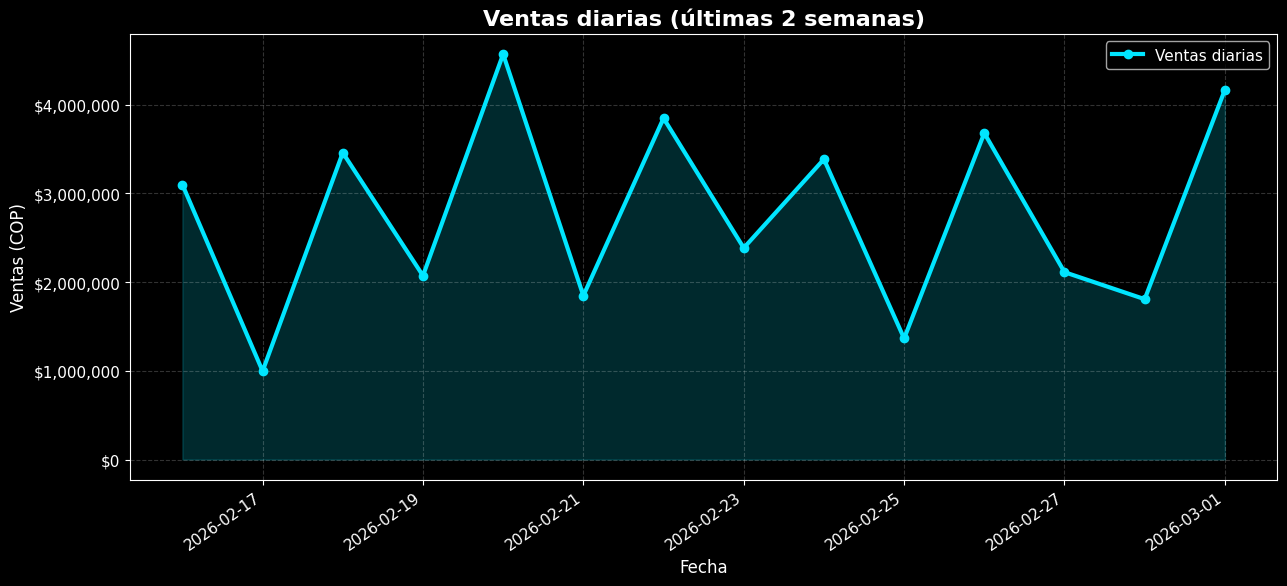

In [13]:
# Gráfica de la serie de 2 semanas: fechas + ventas COP (linea + área)
# rango diario
fechas_14 = pd.date_range(end=pd.Timestamp.today().normalize(), periods=14, freq="D")
# COP aleatorio
ventas_14 = np.random.randint(800_000, 5_500_000, size=len(fechas_14))

df_14 = pd.DataFrame({"fecha": fechas_14, "ventas_cop": ventas_14}).set_index("fecha")

fig, ax = plt.subplots()
ax.plot(df_14.index,
        df_14["ventas_cop"].values,
        color="#00E5FF",
        linewidth=3,
        marker="o",
        markersize=6,
        label="Ventas diarias"
        )
ax.fill_between(df_14.index,
                df_14["ventas_cop"].values,
                color="#00E5FF",
                alpha=0.18
                )

ax.set_title("Ventas diarias (últimas 2 semanas)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (COP)")
ax.yaxis.set_major_formatter(cop_formatter)
ax.legend(frameon=True)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

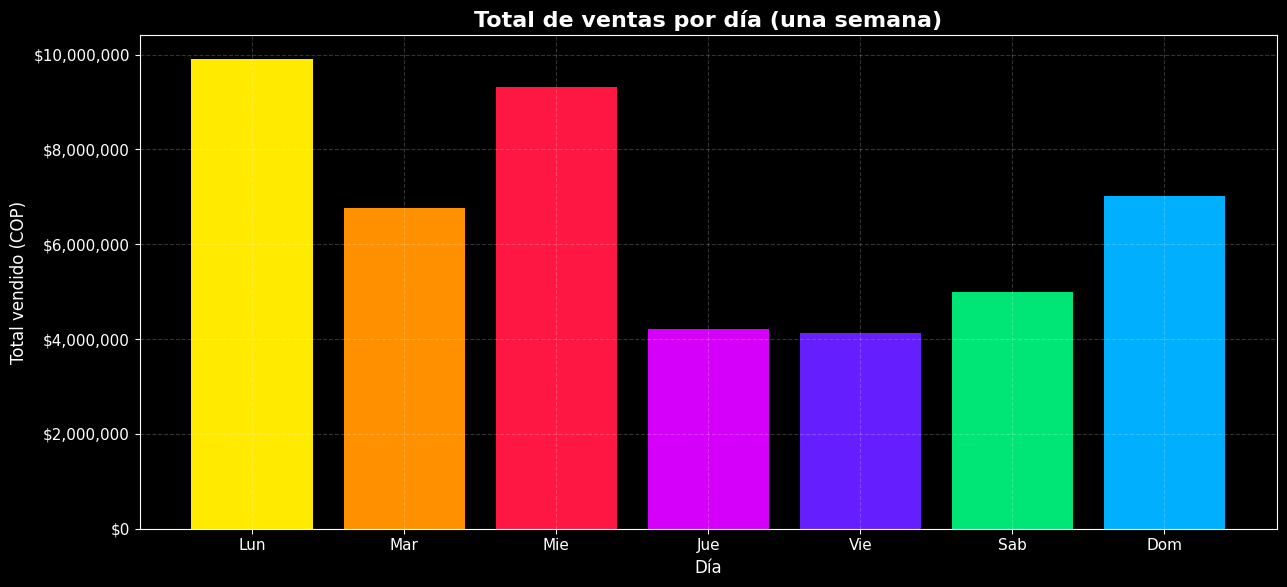

In [16]:
# Gráfica total de ventas en una semana por día (barras)

dias_semana = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]
ventas_semana = np.random.randint(1_500_000, 11_000_000, size=7)

df_week = pd.DataFrame({"dia": dias_semana, "ventas_cop": ventas_semana})

fig, ax = plt.subplots()
# barras
bars = ax.bar(
    df_week["dia"],
    df_week["ventas_cop"],
    color=["#FFEA00", "#FF9100", "#FF1744", "#D500F9", "#651FFF", "#00E676", "#00B0FF"]
)

ax.set_title("Total de ventas por día (una semana)")
ax.set_xlabel("Día")
ax.set_ylabel("Total vendido (COP)")
ax.yaxis.set_major_formatter(cop_formatter)

annotate_bars(ax, bars, fmt_func=lambda v: f"${v:,.0f}", pad=4, color="black")
plt.tight_layout()
plt.show()

/tmp/ipython-input-702/3604422123.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_cash["dia"])


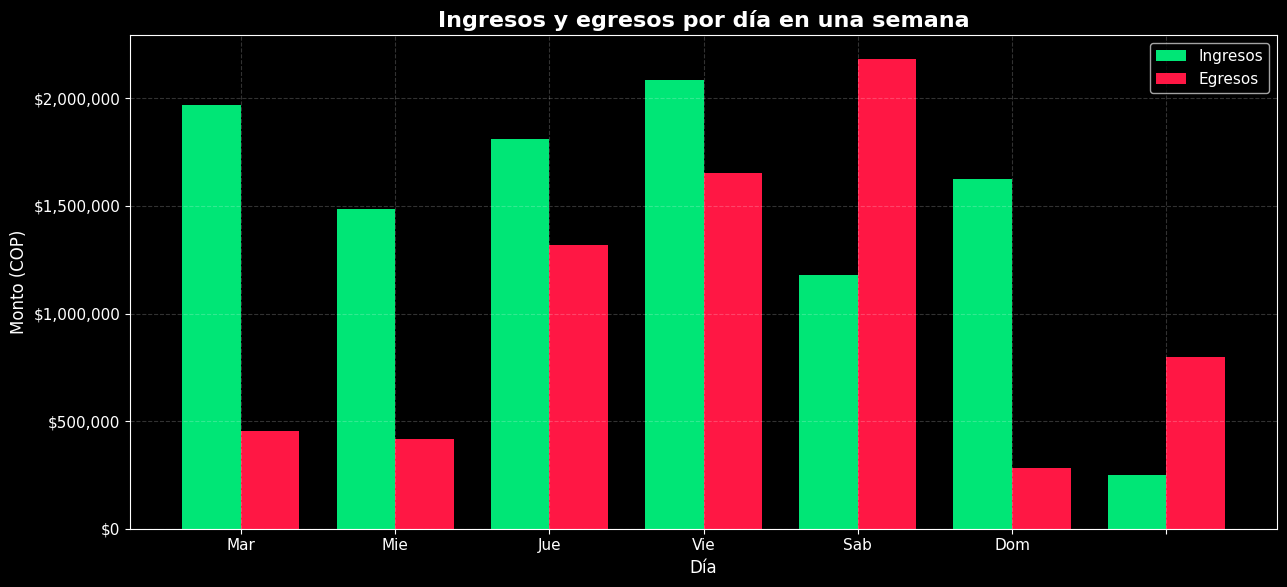

In [17]:
# Gáfica ingresos vs egresos en la semana (barras agrupadas)

ingresos = np.random.randint(200_000, 2_500_000, size=7)
egresos = np.random.randint(150_000, 2_200_000, size=7)

df_cash = pd.DataFrame({"dia": dias_semana, "ingresos_cop": ingresos, "egresos_cop": egresos})

x = np.arange(len(df_cash["dia"]))
w = 0.38

fig, ax = plt.subplots()

bars_ing = ax.bar(x - w/2, df_cash["ingresos_cop"], width=w, color="#00E676", label="Ingresos")
bars_egr = ax.bar(x + w/2, df_cash["egresos_cop"], width=w, color="#FF1744", label="Egresos")

ax.set_title("Ingresos y egresos por día en una semana")
ax.set_xlabel("Día")
ax.set_ylabel("Monto (COP)")
ax.set_xticklabels(df_cash["dia"])
ax.yaxis.set_major_formatter(cop_formatter)
ax.legend(frameon=True)

annotate_bars(ax, bars_ing, fmt_func=lambda v: f"${v:,.0f}", pad=3, color="black")
annotate_bars(ax, bars_egr, fmt_func=lambda v: f"${v:,.0f}", pad=3, color="black")

plt.tight_layout()
plt.show()